# Chapter 35 — The Chain Rule in Computation

## Learning goals

Chapter 34 trained a line model and computed gradients for its weight and bias.

This chapter explains where those gradients come from by splitting one prediction and loss into simple operations.

By the end of this chapter, you should be able to:

1. Break a calculation into intermediate variables.
2. Read and draw a simple computational graph.
3. Explain forward and backward passes.
4. Compute local derivatives for multiply, add, subtract, and square operations.
5. Propagate an upstream derivative through one operation.
6. Use the chain rule to compute loss derivatives for prediction, weight, bias, input, and target.
7. Check parameter gradients numerically.
8. Explain why gradients add when a value affects loss through multiple paths.
9. Use a manual backward pass inside gradient descent.
10. Explain backpropagation as systematic chain-rule bookkeeping.

## Split one computation into simple steps

Use one input, one target, and two parameters:

```python
input_number = 5.0
target_number = 10.0
weight = 1.0
bias = 0.0
```

Instead of writing one dense expression, name every intermediate:

```python
first_value = input_number * weight
prediction = first_value + bias
error = prediction - target_number
loss = error ** 2
```

Each line now represents one simple operation.

## Terms used in this chapter

- A **computational graph** records which values and operations depend on which earlier values.
- An **intermediate value** is a value produced inside a larger computation.
- A **forward pass** evaluates the graph from inputs and parameters to output.
- A **local derivative** describes one operation near its current inputs.
- An **upstream gradient** is the loss derivative arriving from later in the graph.
- A **backward pass** propagates loss derivatives from the output toward earlier values.
- The **chain rule** multiplies derivatives along a dependency path.
- **Gradient accumulation** adds derivative contributions from multiple paths.
- **Backpropagation** applies the chain rule efficiently and systematically through a computational graph.

Backpropagation is organized use of familiar derivative rules, not a separate kind of mathematics.

## Run the forward pass

The forward pass computes values from left to right.

In [1]:
input_number = 5.0
target_number = 10.0
weight = 1.0
bias = 0.0

first_value = input_number * weight
prediction = first_value + bias
error = prediction - target_number
loss = error**2

print("input_number:", input_number)
print("target_number:", target_number)
print("weight:", weight)
print("bias:", bias)
print("first_value = input_number * weight:", first_value)
print("prediction = first_value + bias:", prediction)
print("error = prediction - target_number:", error)
print("loss = error ** 2:", loss)

input_number: 5.0
target_number: 10.0
weight: 1.0
bias: 0.0
first_value = input_number * weight: 5.0
prediction = first_value + bias: 5.0
error = prediction - target_number: -5.0
loss = error ** 2: 25.0


The model predicts `5`, its error is `-5`, and its squared error loss is `25`.

The forward pass produces both the final loss and intermediate values needed later by the backward pass.

## Read the computational graph

The dependency structure is:

```text
input ─┐
       ├─ multiply ─ first_value ─┐
weight ┘                          ├─ add ─ prediction ─┐
bias ────────────────────────────┘                    ├─ subtract ─ error ─ square ─ loss
target ──────────────────────────────────────────────┘
```

The forward pass follows arrows toward loss.

The backward pass follows those dependencies in reverse.

## Draw the graph

Operation nodes are shown as boxes, and value nodes are shown as circles.

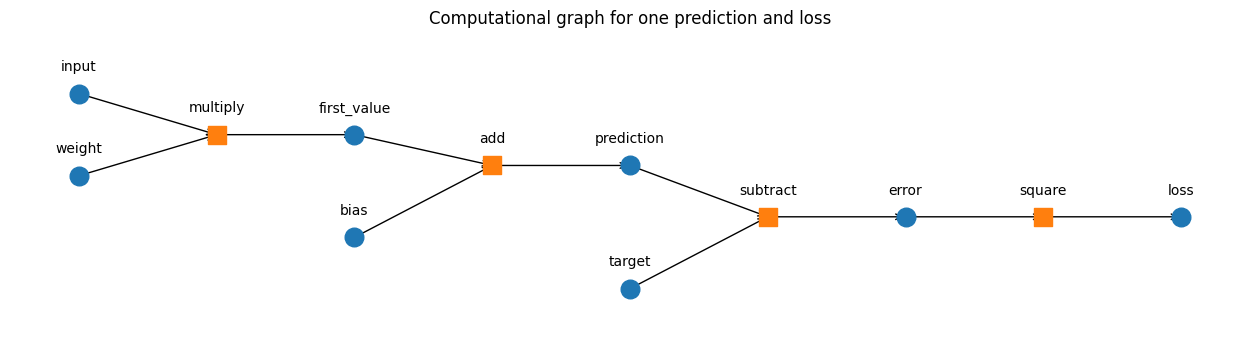

In [2]:
import matplotlib.pyplot as plt

node_positions = {
    "input": (0.0, 2.4),
    "weight": (0.0, 1.6),
    "multiply": (2.0, 2.0),
    "first_value": (4.0, 2.0),
    "bias": (4.0, 1.0),
    "add": (6.0, 1.7),
    "prediction": (8.0, 1.7),
    "target": (8.0, 0.5),
    "subtract": (10.0, 1.2),
    "error": (12.0, 1.2),
    "square": (14.0, 1.2),
    "loss": (16.0, 1.2),
}

operation_nodes = {"multiply", "add", "subtract", "square"}
edges = [
    ("input", "multiply"),
    ("weight", "multiply"),
    ("multiply", "first_value"),
    ("first_value", "add"),
    ("bias", "add"),
    ("add", "prediction"),
    ("prediction", "subtract"),
    ("target", "subtract"),
    ("subtract", "error"),
    ("error", "square"),
    ("square", "loss"),
]

plt.figure(figsize=(16, 4))

for start_node, end_node in edges:
    start_x, start_y = node_positions[start_node]
    end_x, end_y = node_positions[end_node]
    plt.annotate(
        "",
        xy=(end_x, end_y),
        xytext=(start_x, start_y),
        arrowprops={"arrowstyle": "->", "color": "black"},
    )

for node_name, (x_position, y_position) in node_positions.items():
    marker = "s" if node_name in operation_nodes else "o"
    color = "tab:orange" if node_name in operation_nodes else "tab:blue"
    plt.scatter(
        [x_position],
        [y_position],
        marker=marker,
        color=color,
        s=180,
        zorder=3,
    )
    plt.text(x_position, y_position + 0.22, node_name, ha="center")

plt.xlim(-1, 17)
plt.ylim(0, 3)
plt.axis("off")
plt.title("Computational graph for one prediction and loss")
plt.show()

The graph is a dependency map rather than decoration.

It tells the backward pass which local derivatives must be connected.

## Local derivative rules

Each operation has a small derivative rule.

For the current graph:

```text
square:   d loss / d error = 2 × error
subtract: d error / d prediction = 1
subtract: d error / d target = -1
add:      d prediction / d first_value = 1
add:      d prediction / d bias = 1
multiply: d first_value / d weight = input
multiply: d first_value / d input = weight
```

A local derivative is not yet necessarily a final parameter gradient.

The backward pass combines it with the derivative arriving from later in the graph.

## Start the backward pass at the loss

The derivative of loss with respect to itself is `1`.

This seed says that a one-unit change in loss is a one-unit change in loss.

In [3]:
loss_with_respect_to_loss = 1.0
loss_with_respect_to_error = loss_with_respect_to_loss * 2 * error

print("d loss / d loss:", loss_with_respect_to_loss)
print("Local derivative d loss / d error:", 2 * error)
print("Backward result d loss / d error:", loss_with_respect_to_error)

d loss / d loss: 1.0
Local derivative d loss / d error: -10.0
Backward result d loss / d error: -10.0


The derivative `d loss / d error` is `-10`.

Because the error is negative, increasing it toward zero lowers the squared loss.

## Move backward through subtraction

The error is `prediction - target`.

Its local derivatives are `1` with respect to prediction and `-1` with respect to target.

In [4]:
error_with_respect_to_prediction = 1.0
error_with_respect_to_target = -1.0

loss_with_respect_to_prediction = (
    loss_with_respect_to_error * error_with_respect_to_prediction
)
loss_with_respect_to_target = loss_with_respect_to_error * error_with_respect_to_target

print("d loss / d prediction:", loss_with_respect_to_prediction)
print("d loss / d target:", loss_with_respect_to_target)

d loss / d prediction: -10.0
d loss / d target: 10.0


The prediction derivative is `-10`, so raising the too-low prediction reduces loss locally.

The target derivative has the opposite sign because increasing the target makes the current error more negative.

## Move backward through addition

Prediction is `first_value + bias`.

Both local derivatives are `1`, so the arriving derivative passes unchanged to both inputs.

In [5]:
prediction_with_respect_to_first_value = 1.0
prediction_with_respect_to_bias = 1.0

loss_with_respect_to_first_value = (
    loss_with_respect_to_prediction * prediction_with_respect_to_first_value
)
loss_with_respect_to_bias = (
    loss_with_respect_to_prediction * prediction_with_respect_to_bias
)

print("d loss / d first_value:", loss_with_respect_to_first_value)
print("d loss / d bias:", loss_with_respect_to_bias)

d loss / d first_value: -10.0
d loss / d bias: -10.0


The bias gradient is `-10`.

Bias has a short path to loss: `bias → prediction → error → loss`.

## Move backward through multiplication

The first value is `input × weight`.

Its derivative with respect to one factor equals the other factor.

In [6]:
first_value_with_respect_to_weight = input_number
first_value_with_respect_to_input = weight

loss_with_respect_to_weight = (
    loss_with_respect_to_first_value * first_value_with_respect_to_weight
)
loss_with_respect_to_input = (
    loss_with_respect_to_first_value * first_value_with_respect_to_input
)

print("d first_value / d weight:", first_value_with_respect_to_weight)
print("d loss / d weight:", loss_with_respect_to_weight)
print("d first_value / d input:", first_value_with_respect_to_input)
print("d loss / d input:", loss_with_respect_to_input)

d first_value / d weight: 5.0
d loss / d weight: -50.0
d first_value / d input: 1.0
d loss / d input: -10.0


The weight gradient is `-10 × 5 = -50`.

Weight has the longer path `weight → first_value → prediction → error → loss`.

## The central chain-rule calculation

The three requested quantities are:

```text
d loss / d prediction = -10
d prediction / d weight = 5
d loss / d weight = -10 × 5 = -50
```

The middle expression compresses the multiply and add path because bias is held fixed when differentiating prediction with respect to weight.

In [7]:
print("Derivative summary")
print("-" * 44)
print("d loss / d prediction:", loss_with_respect_to_prediction)
print("d prediction / d weight:", first_value_with_respect_to_weight)
print("d loss / d weight:", loss_with_respect_to_weight)
print("d loss / d bias:", loss_with_respect_to_bias)

Derivative summary
--------------------------------------------
d loss / d prediction: -10.0
d prediction / d weight: 5.0
d loss / d weight: -50.0
d loss / d bias: -10.0


These are the same parameter gradients used in Chapters 33 and 34.

The chain rule now explains how they are assembled from local derivatives.

## Put the complete forward and backward passes in functions

The forward pass returns cached values needed by the backward pass.

The backward pass starts with `d loss / d loss = 1` and follows the graph in reverse topological order.

In [8]:
def forward_pass(
    input_number: float,
    target_number: float,
    weight: float,
    bias: float,
) -> dict[str, float]:
    first_value = input_number * weight
    prediction = first_value + bias
    error = prediction - target_number
    loss = error**2

    return {
        "input_number": input_number,
        "target_number": target_number,
        "weight": weight,
        "bias": bias,
        "first_value": first_value,
        "prediction": prediction,
        "error": error,
        "loss": loss,
    }


def backward_pass(forward_values: dict[str, float]) -> dict[str, float]:
    input_number = forward_values["input_number"]
    weight = forward_values["weight"]
    error = forward_values["error"]

    loss_with_respect_to_loss = 1.0
    loss_with_respect_to_error = loss_with_respect_to_loss * 2 * error
    loss_with_respect_to_prediction = loss_with_respect_to_error * 1.0
    loss_with_respect_to_target = loss_with_respect_to_error * -1.0
    loss_with_respect_to_first_value = loss_with_respect_to_prediction * 1.0
    loss_with_respect_to_bias = loss_with_respect_to_prediction * 1.0
    loss_with_respect_to_weight = loss_with_respect_to_first_value * input_number
    loss_with_respect_to_input = loss_with_respect_to_first_value * weight

    return {
        "loss": loss_with_respect_to_loss,
        "error": loss_with_respect_to_error,
        "prediction": loss_with_respect_to_prediction,
        "target_number": loss_with_respect_to_target,
        "first_value": loss_with_respect_to_first_value,
        "bias": loss_with_respect_to_bias,
        "weight": loss_with_respect_to_weight,
        "input_number": loss_with_respect_to_input,
    }

Run both functions and pair each forward value with its loss derivative.

In [9]:
forward_values = forward_pass(
    input_number=5.0,
    target_number=10.0,
    weight=1.0,
    bias=0.0,
)
backward_values = backward_pass(forward_values)

names_in_graph_order = [
    "input_number",
    "weight",
    "first_value",
    "bias",
    "prediction",
    "target_number",
    "error",
    "loss",
]

print("value name".ljust(20), "forward value".rjust(16), "d loss / d value".rjust(20))
print("-" * 60)

for name in names_in_graph_order:
    print(
        name.ljust(20),
        f"{forward_values[name]:>16.6f}",
        f"{backward_values[name]:>20.6f}",
    )

value name              forward value     d loss / d value
------------------------------------------------------------
input_number                 5.000000           -10.000000
weight                       1.000000           -50.000000
first_value                  5.000000           -10.000000
bias                         0.000000           -10.000000
prediction                   5.000000           -10.000000
target_number               10.000000            10.000000
error                       -5.000000           -10.000000
loss                        25.000000             1.000000


Inputs and targets can have derivatives even though ordinary supervised training does not update them.

The learnable parameter gradients in this graph are the entries for weight and bias.

## Check both parameter gradients numerically

Central finite differences independently estimate how loss changes when one parameter is nudged while the other is held fixed.

In [10]:
small_change = 0.0001

weight_plus_loss = forward_pass(5.0, 10.0, 1.0 + small_change, 0.0)["loss"]
weight_minus_loss = forward_pass(5.0, 10.0, 1.0 - small_change, 0.0)["loss"]
numerical_weight_gradient = (weight_plus_loss - weight_minus_loss) / (2 * small_change)

bias_plus_loss = forward_pass(5.0, 10.0, 1.0, 0.0 + small_change)["loss"]
bias_minus_loss = forward_pass(5.0, 10.0, 1.0, 0.0 - small_change)["loss"]
numerical_bias_gradient = (bias_plus_loss - bias_minus_loss) / (2 * small_change)

print("Weight gradient: backward pass =", backward_values["weight"])
print("Weight gradient: numerical     =", numerical_weight_gradient)
print("Bias gradient: backward pass   =", backward_values["bias"])
print("Bias gradient: numerical       =", numerical_bias_gradient)

assert abs(backward_values["weight"] - numerical_weight_gradient) < 1e-8
assert abs(backward_values["bias"] - numerical_bias_gradient) < 1e-8

Weight gradient: backward pass = -50.0
Weight gradient: numerical     = -49.99999999997229
Bias gradient: backward pass   = -10.0
Bias gradient: numerical       = -9.999999999976694


Both checks agree to floating-point precision.

Numerical checking is useful for small examples, while backpropagation scales far better to many parameters.

## Local derivatives and final gradients are different

A local derivative belongs to one operation, such as:

```text
d first_value / d weight = input
```

The final parameter gradient includes everything downstream:

```text
d loss / d weight
= d loss / d error
× d error / d prediction
× d prediction / d first_value
× d first_value / d weight
```

Backpropagation carries the upstream gradient and multiplies by each local derivative.

## Branches require gradient accumulation

If one value affects loss through two paths, its total gradient is the sum of both path contributions.

Consider the small branch `total = value² + 3 × value`.

The derivative is `2 × value + 3`, which adds the square-path and multiply-path contributions.

In [11]:
branch_value = 4.0

square_path_output = branch_value**2
linear_path_output = 3 * branch_value
branch_total = square_path_output + linear_path_output

square_path_gradient = 2 * branch_value
linear_path_gradient = 3.0
accumulated_gradient = square_path_gradient + linear_path_gradient

print("Forward total:", branch_total)
print("Square-path contribution:", square_path_gradient)
print("Linear-path contribution:", linear_path_gradient)
print("Accumulated d total / d value:", accumulated_gradient)

assert accumulated_gradient == 11.0

Forward total: 28.0
Square-path contribution: 8.0
Linear-path contribution: 3.0
Accumulated d total / d value: 11.0


Multiplication handles derivatives along one path, while addition combines contributions from separate paths.

Large neural-network graphs contain extensive branching, so automatic gradient accumulation is essential.

## Use the backward pass for one update

Compute both parameter gradients at the same old values, then update both parameters simultaneously.

In [12]:
learning_rate = 0.01

updated_weight = forward_values["weight"] - learning_rate * backward_values["weight"]
updated_bias = forward_values["bias"] - learning_rate * backward_values["bias"]

updated_forward_values = forward_pass(
    input_number=5.0,
    target_number=10.0,
    weight=updated_weight,
    bias=updated_bias,
)

print("Old parameters:", (forward_values["weight"], forward_values["bias"]))
print("Parameter gradients:", (backward_values["weight"], backward_values["bias"]))
print("Updated parameters:", (updated_weight, updated_bias))
print("Old loss:", forward_values["loss"])
print("New loss:", updated_forward_values["loss"])

assert updated_forward_values["loss"] < forward_values["loss"]

Old parameters: (1.0, 0.0)
Parameter gradients: (-50.0, -10.0)
Updated parameters: (1.5, 0.1)
Old loss: 25.0
New loss: 5.760000000000002


Both gradients are negative, so both parameters increase and raise the too-low prediction.

## Train using the manual backward pass

Recompute the forward and backward passes after every update because derivative values depend on the current values.

In [13]:
training_weight = 1.0
training_bias = 0.0
number_of_steps = 12

print(
    "step | weight | bias | prediction | loss | "
    "dL/dw | dL/db | updated weight | updated bias"
)
print("-" * 108)

for step in range(number_of_steps):
    step_forward = forward_pass(
        input_number=5.0,
        target_number=10.0,
        weight=training_weight,
        bias=training_bias,
    )
    step_backward = backward_pass(step_forward)

    next_weight = training_weight - learning_rate * step_backward["weight"]
    next_bias = training_bias - learning_rate * step_backward["bias"]

    print(
        f"{step:>4} | "
        f"{training_weight:>8.5f} | "
        f"{training_bias:>8.5f} | "
        f"{step_forward['prediction']:>10.5f} | "
        f"{step_forward['loss']:>9.5f} | "
        f"{step_backward['weight']:>8.5f} | "
        f"{step_backward['bias']:>8.5f} | "
        f"{next_weight:>14.5f} | "
        f"{next_bias:>12.5f}"
    )

    training_weight = next_weight
    training_bias = next_bias

final_training_values = forward_pass(
    5.0,
    10.0,
    training_weight,
    training_bias,
)

print()
print("Final prediction:", final_training_values["prediction"])
print("Final loss:", final_training_values["loss"])

step | weight | bias | prediction | loss | dL/dw | dL/db | updated weight | updated bias
------------------------------------------------------------------------------------------------------------
   0 |  1.00000 |  0.00000 |    5.00000 |  25.00000 | -50.00000 | -10.00000 |        1.50000 |      0.10000
   1 |  1.50000 |  0.10000 |    7.60000 |   5.76000 | -24.00000 | -4.80000 |        1.74000 |      0.14800
   2 |  1.74000 |  0.14800 |    8.84800 |   1.32710 | -11.52000 | -2.30400 |        1.85520 |      0.17104
   3 |  1.85520 |  0.17104 |    9.44704 |   0.30576 | -5.52960 | -1.10592 |        1.91050 |      0.18210
   4 |  1.91050 |  0.18210 |    9.73458 |   0.07045 | -2.65421 | -0.53084 |        1.93704 |      0.18741
   5 |  1.93704 |  0.18741 |    9.87260 |   0.01623 | -1.27402 | -0.25480 |        1.94978 |      0.18996
   6 |  1.94978 |  0.18996 |    9.93885 |   0.00374 | -0.61153 | -0.12231 |        1.95589 |      0.19118
   7 |  1.95589 |  0.19118 |    9.97065 |   0.00086 | -0

This is backpropagation inside a tiny training loop.

The graph structure stays fixed, while forward values and backward derivatives change at every step.

## One example cannot identify two unique parameters

Any pair satisfying `5 × weight + bias = 10` gives zero loss for this one training example.

For example, `(2, 0)`, `(1.8, 1)`, and `(1, 5)` all predict `10`.

The training run approaches one zero-loss pair determined by its starting point and update path, not a uniquely recoverable weight and bias.

Chapter 34 used several distinct inputs, which supplied enough information to recover a particular line.

In [14]:
zero_loss_parameter_pairs = [
    (2.0, 0.0),
    (1.8, 1.0),
    (1.0, 5.0),
]

for checked_weight, checked_bias in zero_loss_parameter_pairs:
    checked_values = forward_pass(
        5.0,
        10.0,
        checked_weight,
        checked_bias,
    )
    print(
        f"weight={checked_weight:.1f}, "
        f"bias={checked_bias:.1f}, "
        f"prediction={checked_values['prediction']:.1f}, "
        f"loss={checked_values['loss']:.1f}"
    )

weight=2.0, bias=0.0, prediction=10.0, loss=0.0
weight=1.8, bias=1.0, prediction=10.0, loss=0.0
weight=1.0, bias=5.0, prediction=10.0, loss=0.0


Low training loss does not by itself prove that each internal parameter has one uniquely correct interpretation.

## Backpropagation is organized bookkeeping

The forward pass records intermediate values.

The backward pass reuses them while applying local derivative rules in reverse order.

At branches, contributions are accumulated.

This organization avoids repeatedly expanding one enormous symbolic derivative and lets each graph operation implement a small reusable backward rule.

## A clean forward-backward pipeline

This final cell verifies the complete manual computation and one update.

In [15]:
pipeline_forward = forward_pass(
    input_number=5.0,
    target_number=10.0,
    weight=1.0,
    bias=0.0,
)
pipeline_backward = backward_pass(pipeline_forward)

pipeline_updated_weight = (
    pipeline_forward["weight"] - 0.01 * pipeline_backward["weight"]
)
pipeline_updated_bias = pipeline_forward["bias"] - 0.01 * pipeline_backward["bias"]
pipeline_updated_forward = forward_pass(
    5.0,
    10.0,
    pipeline_updated_weight,
    pipeline_updated_bias,
)

assert pipeline_forward["loss"] == 25.0
assert pipeline_backward["prediction"] == -10.0
assert pipeline_backward["weight"] == -50.0
assert pipeline_backward["bias"] == -10.0
assert pipeline_updated_forward["loss"] < pipeline_forward["loss"]

print("Forward loss:", pipeline_forward["loss"])
print("d loss / d prediction:", pipeline_backward["prediction"])
print("d prediction / d weight:", pipeline_forward["input_number"])
print("d loss / d weight:", pipeline_backward["weight"])
print("d loss / d bias:", pipeline_backward["bias"])
print("Updated weight:", pipeline_updated_weight)
print("Updated bias:", pipeline_updated_bias)
print("Updated loss:", pipeline_updated_forward["loss"])
print("All chain-rule checks passed.")

Forward loss: 25.0
d loss / d prediction: -10.0
d prediction / d weight: 5.0
d loss / d weight: -50.0
d loss / d bias: -10.0
Updated weight: 1.5
Updated bias: 0.1
Updated loss: 5.760000000000002
All chain-rule checks passed.


## What not to do

- Do not treat backpropagation as unrelated new mathematics.
- Do not confuse a local derivative with the final loss gradient.
- Do not forget to seed the backward pass with `d loss / d loss = 1`.
- Do not use stale forward values after parameters change.
- Do not update one parameter before computing the other parameter's gradient at the current point.
- Do not multiply path contributions when a branch requires them to be added.
- Do not assume one example uniquely identifies multiple parameters.

## Gotchas

- The forward pass computes values; the backward pass computes loss derivatives.
- The chain rule multiplies local derivatives along a path.
- Gradient accumulation adds contributions from multiple paths.
- Weight and bias have different paths to loss.
- Inputs and targets can have derivatives even when they are not trainable parameters.
- Intermediate forward values are cached because backward rules often need them.
- The graph structure can stay fixed while all numerical derivatives change.

## Takeaways

The forward computation is:

```python
first_value = input_number * weight
prediction = first_value + bias
error = prediction - target_number
loss = error ** 2
```

The backward pass starts at loss and applies local derivative rules in reverse.

For the starting values:

```text
d loss / d prediction = -10
d prediction / d weight = 5
d loss / d weight = -50
d loss / d bias = -10
```

Backpropagation is the chain rule plus organized traversal and gradient accumulation through a computational graph.

## What comes next

The next chapter introduces automatic differentiation conceptually.

Instead of writing every backward rule invocation by hand, we will see how software records operations and computes gradients automatically.